# Python Data Processing and Visualisation

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import libraries
Objective:

To load the Python libraries needed for data cleaning, manipulation, analysis, and visualisation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

We start by importing the main Python libraries used for tabular data handling and visualisation. This step is necessary because pandas and NumPy are used for cleaning and analysis, while matplotlib and seaborn are used to create charts for interpretation.



## Load datasets
Objective:

To read the NorthStar CSV files into Python data frames for further processing.



In [4]:
base_path = "/content/drive/MyDrive/DBA NOTEBOOKS/"

orders = pd.read_csv(base_path + "orders.csv")
deliveries = pd.read_csv(base_path + "deliveries.csv")
complaints = pd.read_csv(base_path + "complaints.csv")
incidents = pd.read_csv(base_path + "incidents.csv")
customers = pd.read_csv(base_path + "customers.csv")
drivers = pd.read_csv(base_path + "drivers.csv")
vehicles = pd.read_csv(base_path + "vehicles.csv")
hubs = pd.read_csv(base_path + "hubs.csv")
app_events = pd.read_csv(base_path + "app_events.csv")

This step loads all the raw NorthStar files so that they can be cleaned and analysed in Python. Using a single base path keeps the notebook organised and makes it easier to reuse the files across all sections.



## Quick inspection
Objective:

To inspect the shape, structure, and basic quality of the datasets before cleaning.



In [5]:
orders.head()
deliveries.head()
complaints.head()
incidents.head()

,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0


We inspect the first few rows to confirm that the data loaded correctly and to see the column structure. This helps identify any obvious formatting issues, missing values, or unexpected labels before deeper analysis begins.



## Data overview
Objective:

To check data types, null values, and summary statistics for the main tables.

In [6]:
orders.info()
deliveries.info()
complaints.info()
incidents.info()

orders.describe(include='all')
deliveries.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1250 non-null   object 
 1   customer_id            1250 non-null   object 
 2   service_type           1250 non-null   object 
 3   order_created_at       1250 non-null   object 
 4   promised_window_hours  1250 non-null   int64  
 5   pickup_zone            1250 non-null   object 
 6   dropoff_zone           1250 non-null   object 
 7   priority_level         1250 non-null   object 
 8   order_value            1250 non-null   float64
 9   booking_channel        1225 non-null   object 
 10  special_handling_flag  1250 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 107.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Cou

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950,950,950,950,950,950,931,950,950.000000,950.000000,950.000000,936.000000,950.000000
unique,950,950,170,120,8,950,931,3,NaN,NaN,NaN,NaN,NaN
top,DL00950,O00744,D102,V047,H01,2025-04-23 05:31:00,2025-04-23 09:48:21.154957,OnTime,NaN,NaN,NaN,NaN,NaN
freq,1,1,13,17,136,1,1,616,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.909316,0.969474,0.072632,3.864679,12.841295
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.477907,1.093189,0.259667,0.894420,4.336468
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000,0.000000,0.000000,1.000000,2.500000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.135000,0.000000,0.000000,3.360000,9.925000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.840000,1.000000,0.000000,4.040000,12.645000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.835000,2.000000,0.000000,4.550000,15.697500


This step provides a structured overview of the data quality and variable types. It is important because good analysis depends on knowing whether fields are numeric, categorical, or datetime, and whether there are any missing values that need attention.



## Standardise text fields
Objective:

To clean categorical fields such as zone names and status labels so that comparisons are consistent.



In [7]:
for col in ['pickup_zone', 'dropoff_zone']:
    if col in orders.columns:
        orders[col] = orders[col].astype(str).str.strip().str.title()

for col in ['delivery_status']:
    if col in deliveries.columns:
        deliveries[col] = deliveries[col].astype(str).str.strip().str.title()

for col in ['complaint_type', 'severity', 'status']:
    if col in complaints.columns:
        complaints[col] = complaints[col].astype(str).str.strip().str.title()

for col in ['incident_type', 'status']:
    if col in incidents.columns:
        incidents[col] = incidents[col].astype(str).str.strip().str.title()

This cleaning step standardises text values so that categories are written in the same format. It is necessary because inconsistent spelling or capitalisation can split the same category into multiple groups and distort the results.



## Date conversion
Objective:

To convert timestamp fields into proper datetime format for time-based analysis.

In [8]:
date_cols = ['order_created_at']
for col in date_cols:
    if col in orders.columns:
        orders[col] = pd.to_datetime(orders[col], errors='coerce')

for col in ['dispatch_time', 'delivery_completed_at']:
    if col in deliveries.columns:
        deliveries[col] = pd.to_datetime(deliveries[col], errors='coerce')

for col in ['created_at']:
    if col in complaints.columns:
        complaints[col] = pd.to_datetime(complaints[col], errors='coerce')

for col in ['reported_at']:
    if col in incidents.columns:
        incidents[col] = pd.to_datetime(incidents[col], errors='coerce')

This step ensures that date and time values are usable for analysis and filtering. Without converting them into datetime format, it would be difficult to study trends over time or calculate durations correctly.



## Delivery duration feature
Objective:

To create a new feature that measures how long each delivery took.



In [9]:
deliveries['delivery_duration_hours'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

This feature makes the analysis more useful by turning two timestamps into a single performance measure. It helps us assess whether longer delivery times are linked to delays, failures, or customer dissatisfaction.



## Delivery status summary
Objective:

To calculate the number and percentage of deliveries in each status category.


In [10]:
delivery_status_summary = deliveries['delivery_status'].value_counts().reset_index()
delivery_status_summary.columns = ['delivery_status', 'count']
delivery_status_summary['percentage'] = (delivery_status_summary['count'] / delivery_status_summary['count'].sum() * 100).round(2)

delivery_status_summary

,delivery_status,count,percentage
0,Ontime,616,64.84
1,Delayed,202,21.26
2,Failed,132,13.89


This gives a simple but important summary of delivery reliability. It is useful because it immediately shows how much of the operation is on time versus delayed or failed.



## Complaint type summary
Objective:

To identify the most common complaint categories in the dataset.



In [11]:
complaint_type_summary = complaints['complaint_type'].value_counts().reset_index()
complaint_type_summary.columns = ['complaint_type', 'count']

complaint_type_summary

,complaint_type,count
0,Delay,101
1,Missedpickup,64
2,Appissue,53
3,Driverbehaviour,51
4,Supportexperience,20
5,Billing,16
6,Damage,15


We use this summary to see which customer problems occur most often. This helps connect service complaints to the operational failures that may be causing them.



## Incident type summary
Objective:

To identify the most frequent operational incident types.



In [12]:
incident_type_summary = incidents['incident_type'].value_counts().reset_index()
incident_type_summary.columns = ['incident_type', 'count']

incident_type_summary

,incident_type,count
0,Proofmissing,46
1,Customernoshow,44
2,Routedeviation,43
3,Vehiclefault,37
4,Batteryalert,36
5,Appsyncerror,31
6,Temperatureissue,29
7,Safetynearmiss,14


This summary helps reveal which operational issues happen most often, such as route deviation or proof missing. It is important because incidents often explain why deliveries fail or customers complain.

## Consolidating All Datasets into One Dataframe
Objective:


To combine the NorthStar CSV files into a single consolidated dataframe for integrated Python analysis.

In [5]:
consolidated_df = orders.merge(deliveries, on="order_id", how="left")

if "order_id" in complaints.columns:
    consolidated_df = consolidated_df.merge(
        complaints[["order_id", "complaint_type", "severity", "status"]],
        on="order_id",
        how="left"
    )

if "order_id" in incidents.columns:
    consolidated_df = consolidated_df.merge(
        incidents[["order_id", "incident_type"]],
        on="order_id",
        how="left"
    )

for df, key in [(customers, "customer_id"), (drivers, "driver_id"), (vehicles, "vehicle_id"), (hubs, "hub_id")]:
    if key in df.columns and key in consolidated_df.columns:
        consolidated_df = consolidated_df.merge(df, on=key, how="left")

print(consolidated_df.shape)
consolidated_df.head()

(1285, 52)


,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,delivery_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,complaint_type,severity,status,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,DL00937,D047,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2.0,0.0,4.29,15.82,NaN,NaN,NaN,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active,South,FullTime,7.0,64.6,4.70,Morning,1.0,Hybrid,WEST,2024-08-16 01:10:00,93.8,98472.0,InRepair,v2.0,North Exchange,North,Dispatch,82.0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20,WEST,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,DL00925,D041,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2.0,0.0,3.70,13.16,AppIssue,Medium,Open,42,north,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active,EAST,PartTime,3.0,88.2,3.67,Morning,1.0,CargoVan,East,2024-06-23 11:24:00,60.1,31876.0,Active,v2.0,South Link,South,Dispatch,78.0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,DL00002,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1.0,0.0,5.00,13.41,NaN,NaN,NaN,50,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,Ctr,PartTime,11.0,69.2,4.61,Evening,1.0,Diesel,AIRPORT,2025-09-17 08:52:00,68.6,78468.0,Active,v2.2,South Link,South,Dispatch,78.0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,DL00671,D054,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1.0,0.0,4.38,13.53,MissedPickup,Medium,Resolved,23,SOUTH,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active,WEST,FullTime,3.0,80.1,4.32,Morning,1.0,Hybrid,AIRPORT,2024-05-28 05:33:00,NaN,191353.0,Active,v2.1,East Dock,East,Warehouse,74.0


This creates one analysis-ready dataframe and keeps the operational relationships together in a single place. Combining datasets this way is important because it reduces fragmentation and helps reveal links between orders, deliveries, complaints, and incidents.



## Delivery status chart
Objective:

To visualise the distribution of delivery outcomes.



/tmp/ipykernel_17615/4141074936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=deliveries, x='delivery_status', palette='Set2')


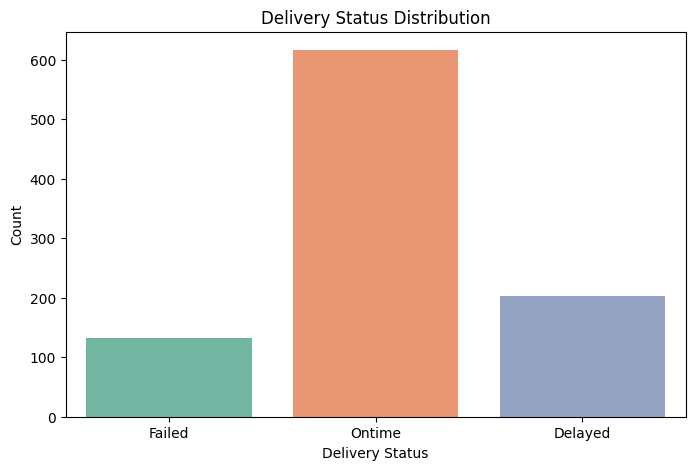

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=deliveries, x='delivery_status', palette='Set2')
plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Count')
plt.show()

This chart gives a clear visual summary of delivery performance. It is included because charts are easier to interpret than raw tables when comparing the relative size of each delivery outcome category.



## Complaint type chart
Objective:

To visualise the most frequent complaint categories.


/tmp/ipykernel_17615/666168796.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='coolwarm')


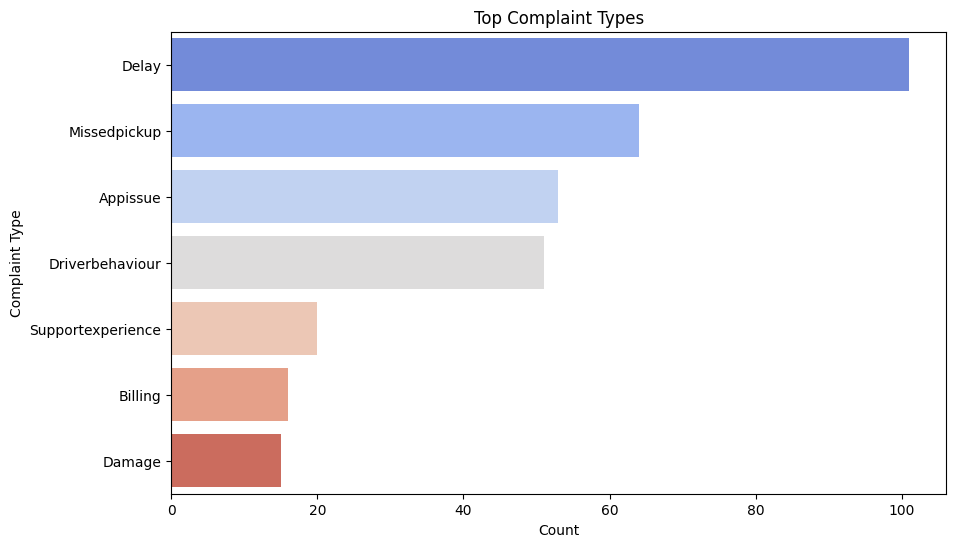

In [15]:
plt.figure(figsize=(10,6))
top_complaints = complaints['complaint_type'].value_counts().head(10)
sns.barplot(x=top_complaints.values, y=top_complaints.index, palette='coolwarm')
plt.title('Top Complaint Types')
plt.xlabel('Count')
plt.ylabel('Complaint Type')
plt.show()

This chart shows the most common customer issues in a simple visual format. It helps identify whether complaints are mainly about operational delays, service failures, or support issues.

## Rating by delivery status
Objective:

To compare customer ratings across delivery outcomes.



/tmp/ipykernel_17615/1059387464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deliveries, x='delivery_status', y='customer_rating_post_delivery', palette='Pastel1')


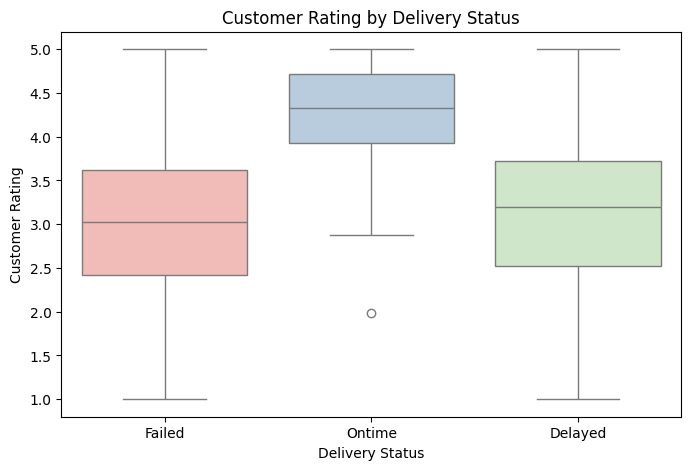

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=deliveries, x='delivery_status', y='customer_rating_post_delivery', palette='Pastel1')
plt.title('Customer Rating by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Customer Rating')
plt.show()

This plot helps check whether delayed or failed deliveries receive lower ratings than on-time ones. It is useful because it connects operational performance directly to customer satisfaction.

## NumPy analysis
Objective:

To use NumPy directly for numerical summaries and variability checks.

In [18]:
import numpy as np

np.mean(deliveries['customer_rating_post_delivery'])
np.std(deliveries['manual_route_override_count'])
np.median(deliveries['fuel_or_charge_cost'])

np.float64(12.645)

This step shows direct use of NumPy, which the marking guide expects. It also helps summarise key numeric variables quickly so we can compare customer satisfaction, route overrides, and operating cost.



## Grouped analysis
Objective:

To compare service performance by delivery outcome.

In [19]:
deliveries.groupby('delivery_status')[[
    'customer_rating_post_delivery',
    'manual_route_override_count',
    'fuel_or_charge_cost'
]].mean().round(2)

,customer_rating_post_delivery,manual_route_override_count,fuel_or_charge_cost
delivery_status,,,
Delayed,3.11,1.07,13.14
Failed,3.05,1.04,13.15
Ontime,4.28,0.92,12.68


This is important because it moves beyond simple counts and starts comparing average performance across categories. It helps answer whether failed or delayed deliveries are associated with lower ratings, higher route overrides, or higher costs.

## Cross-tab analysis
Objective:

To explore the relationship between delivery status and complaint severity.

In [20]:
merged = orders.merge(deliveries, on='order_id', how='left').merge(
    complaints[['order_id', 'severity']], on='order_id', how='left'
)

pd.crosstab(merged['delivery_status'], merged['severity'], margins=True)

severity,High,Low,Medium,All
delivery_status,,,,
Delayed,12,6,30,48
Failed,13,5,17,35
Ontime,28,35,86,149
All,53,46,133,232


This step shows how two categorical variables relate to each other. Crosstabs are useful because they reveal whether bad delivery outcomes are concentrated in more serious complaints, which strengthens the business interpretation of the results.



## Pivot table
Objective:

To summarise average customer ratings by zone and delivery status.

In [7]:
pd.pivot_table(
    deliveries,
    values='customer_rating_post_delivery',
    index='delivery_status',
    aggfunc='mean'
).round(2)

,customer_rating_post_delivery
delivery_status,
Delayed,3.11
Failed,3.05
OnTime,4.28


This gives a more structured summary of ratings by outcome category. A pivot table is useful in reports because it turns raw data into a compact analytical view that is easy to interpret and compare.



## Save cleaned file
Objective:

To store the cleaned merged dataset for later use in MongoDB and optimisation work.

In [17]:
order_delivery.to_csv("/content/drive/MyDrive/DBA NOTEBOOKS/order_delivery_cleaned.csv", index=False)

Saving the cleaned dataset makes the workflow reproducible and allows the same prepared data to be reused later in the MongoDB section. This is also useful for keeping the project organised inside the GitHub repository.

